<a href="https://colab.research.google.com/github/HK25abm/Transformer-Phishing-Detection/blob/main/Final_Model_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

bert = pd.read_csv("bert_results.csv")
roberta = pd.read_csv("roberta_results.csv")
deberta = pd.read_csv("deberta_results.csv")

comparison = pd.concat(
    [bert, roberta, deberta],
    ignore_index=True
)

comparison

,Model,Checkpoint,Accuracy,Precision,Recall,F1-score,ROC-AUC,Training Time Seconds,Best Checkpoint,Maximum Sequence Length,Epochs,Learning Rate,Precision Mode
0,BERT,bert-base-uncased,0.987333,0.987333,0.987333,0.987333,0.998907,732.144890,./final_models/bert/checkpoint-2625,NaN,NaN,NaN,NaN
1,RoBERTa,roberta-base,0.989000,0.991293,0.986667,0.988974,0.999080,695.516380,./final_models/roberta/checkpoint-1750,NaN,NaN,NaN,NaN
2,DeBERTa,microsoft/deberta-v3-base,0.989667,0.989993,0.989333,0.989663,0.999216,3077.268993,NaN,256.0,3.0,0.00001,FP32


In [2]:
comparison.to_csv(
    "final_model_comparison.csv",
    index=False
)

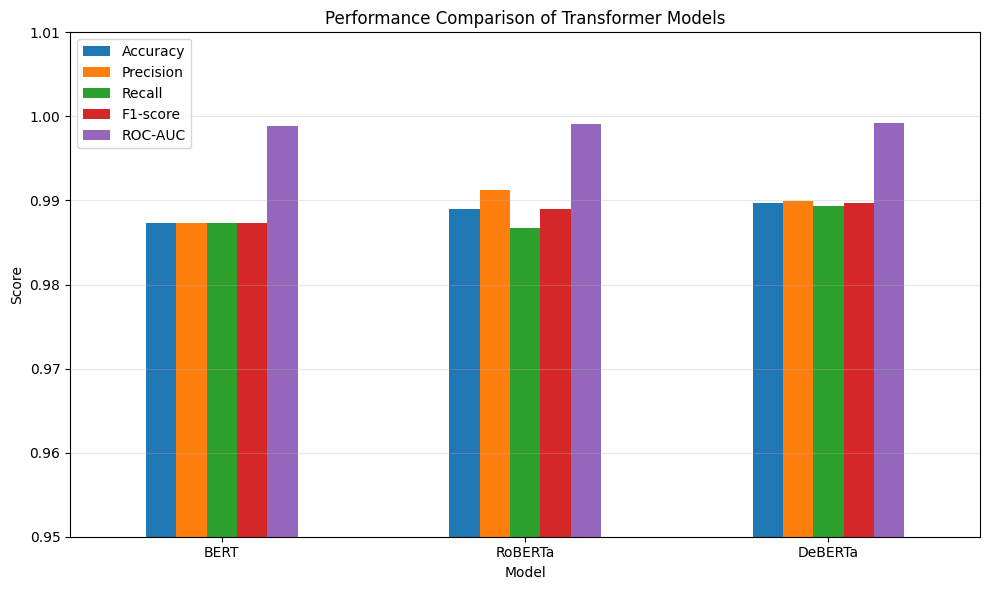

In [3]:
import matplotlib.pyplot as plt

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "ROC-AUC"
]

plot_df = comparison.set_index("Model")[metrics]

ax = plot_df.plot(
    kind="bar",
    figsize=(10,6)
)

plt.ylabel("Score")
plt.ylim(0.95, 1.01)
plt.title("Performance Comparison of Transformer Models")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    "model_performance_comparison.png",
    dpi=300
)

plt.show()

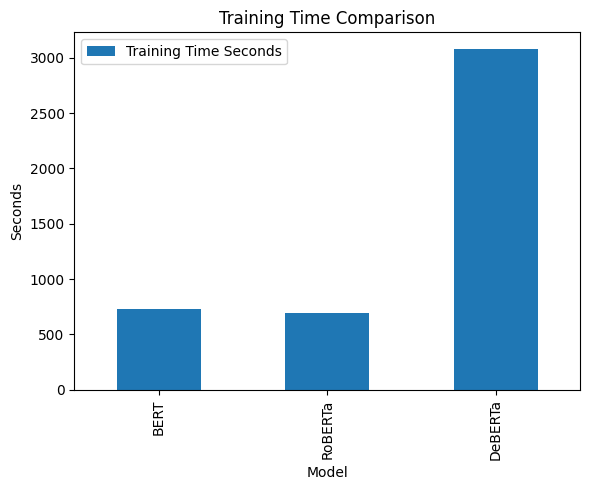

In [4]:
comparison.plot(
    x="Model",
    y="Training Time Seconds",
    kind="bar",
    figsize=(6,5)
)

plt.ylabel("Seconds")
plt.title("Training Time Comparison")

plt.tight_layout()

plt.savefig(
    "training_time_comparison.png",
    dpi=300
)

plt.show()

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

In [6]:
bert = pd.read_csv("bert_test_predictions.csv")

roberta = pd.read_csv("roberta_test_predictions.csv")

deberta = pd.read_csv("deberta_predictions.csv")

In [7]:
print(bert.columns)

print(roberta.columns)

print(deberta.columns)

Index(['text', 'label', 'source', 'email_type', 'urls', 'sample_id',
       'predicted_label', 'legitimate_probability', 'phishing_probability'],
      dtype='object')
Index(['text', 'label', 'source', 'email_type', 'urls', 'sample_id',
       'predicted_label', 'legitimate_probability', 'phishing_probability'],
      dtype='object')
Index(['text', 'label', 'source', 'email_type', 'urls', 'sample_id',
       'predicted_label', 'predicted_class', 'legitimate_probability',
       'phishing_probability', 'correct_prediction'],
      dtype='object')


In [8]:
fpr_bert, tpr_bert, _ = roc_curve(
    bert["label"],
    bert["phishing_probability"]
)

auc_bert = roc_auc_score(
    bert["label"],
    bert["phishing_probability"]
)

NameError: name 'fpr_roberta' is not defined

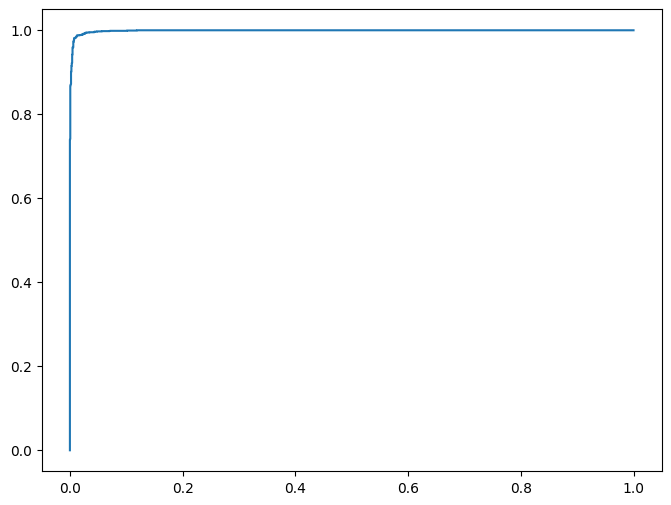

In [9]:
plt.figure(figsize=(8,6))

plt.plot(fpr_bert, tpr_bert,
         label=f"BERT (AUC={auc_bert:.4f})")

plt.plot(fpr_roberta, tpr_roberta,
         label=f"RoBERTa (AUC={auc_roberta:.4f})")

plt.plot(fpr_deberta, tpr_deberta,
         label=f"DeBERTa (AUC={auc_deberta:.4f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of BERT, RoBERTa and DeBERTa")
plt.legend()

plt.grid(True)

plt.savefig(
    "combined_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
print(bert.columns.tolist())
print(roberta.columns.tolist())
print(deberta.columns.tolist())

['text', 'label', 'source', 'email_type', 'urls', 'sample_id', 'predicted_label', 'legitimate_probability', 'phishing_probability']
['text', 'label', 'source', 'email_type', 'urls', 'sample_id', 'predicted_label', 'legitimate_probability', 'phishing_probability']
['text', 'label', 'source', 'email_type', 'urls', 'sample_id', 'predicted_label', 'predicted_class', 'legitimate_probability', 'phishing_probability', 'correct_prediction']


In [11]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr_bert, tpr_bert, _ = roc_curve(
    bert["label"],
    bert["phishing_probability"]
)

auc_bert = roc_auc_score(
    bert["label"],
    bert["phishing_probability"]
)

In [12]:
print(bert.columns.tolist())
print(roberta.columns.tolist())
print(deberta.columns.tolist())

['text', 'label', 'source', 'email_type', 'urls', 'sample_id', 'predicted_label', 'legitimate_probability', 'phishing_probability']
['text', 'label', 'source', 'email_type', 'urls', 'sample_id', 'predicted_label', 'legitimate_probability', 'phishing_probability']
['text', 'label', 'source', 'email_type', 'urls', 'sample_id', 'predicted_label', 'predicted_class', 'legitimate_probability', 'phishing_probability', 'correct_prediction']


In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

In [14]:
# ------------------------
# BERT
# ------------------------

fpr_bert, tpr_bert, _ = roc_curve(
    bert["label"],
    bert["phishing_probability"]
)

auc_bert = roc_auc_score(
    bert["label"],
    bert["phishing_probability"]
)


# ------------------------
# RoBERTa
# ------------------------

fpr_roberta, tpr_roberta, _ = roc_curve(
    roberta["label"],
    roberta["phishing_probability"]
)

auc_roberta = roc_auc_score(
    roberta["label"],
    roberta["phishing_probability"]
)


# ------------------------
# DeBERTa
# ------------------------

fpr_deberta, tpr_deberta, _ = roc_curve(
    deberta["label"],
    deberta["phishing_probability"]
)

auc_deberta = roc_auc_score(
    deberta["label"],
    deberta["phishing_probability"]
)

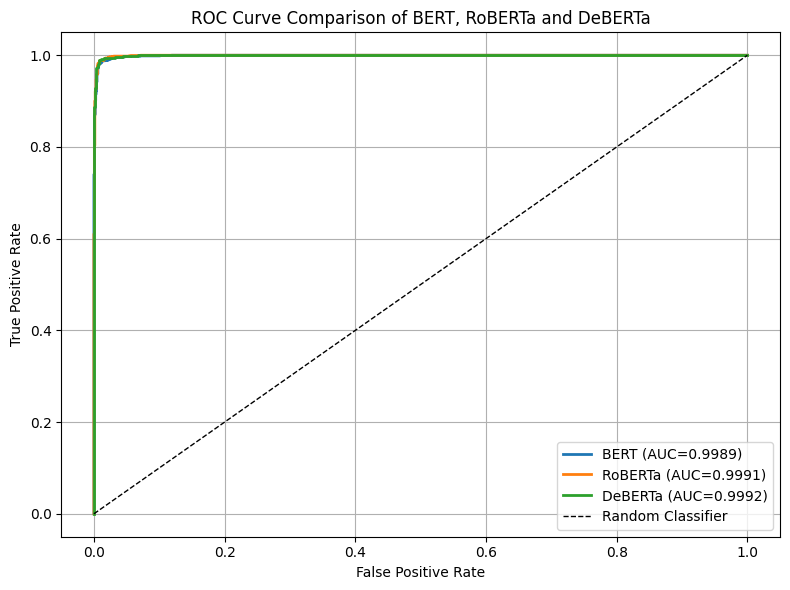

In [15]:
plt.figure(figsize=(8,6))

plt.plot(
    fpr_bert,
    tpr_bert,
    linewidth=2,
    label=f"BERT (AUC={auc_bert:.4f})"
)

plt.plot(
    fpr_roberta,
    tpr_roberta,
    linewidth=2,
    label=f"RoBERTa (AUC={auc_roberta:.4f})"
)

plt.plot(
    fpr_deberta,
    tpr_deberta,
    linewidth=2,
    label=f"DeBERTa (AUC={auc_deberta:.4f})"
)

# Random classifier
plt.plot(
    [0,1],
    [0,1],
    "k--",
    linewidth=1,
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of BERT, RoBERTa and DeBERTa")

plt.legend(loc="lower right")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "combined_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

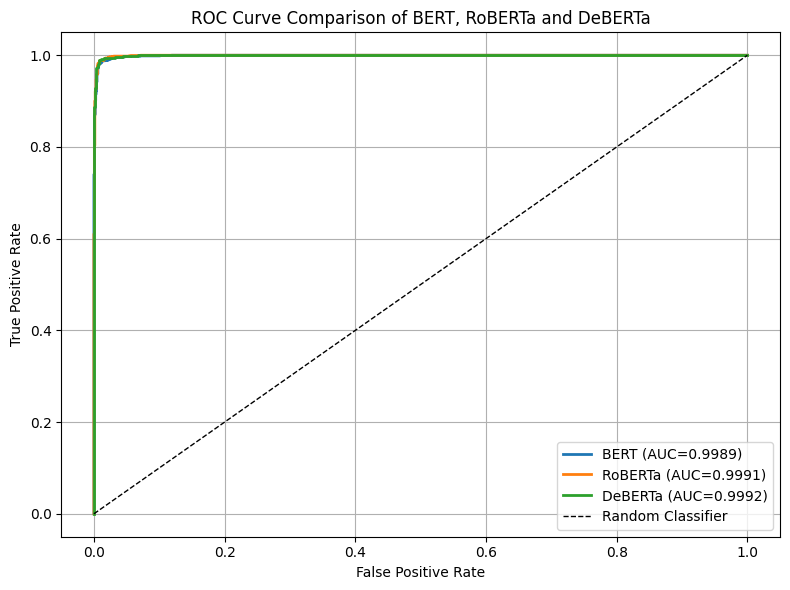

In [16]:
plt.figure(figsize=(8,6))

plt.plot(
    fpr_bert,
    tpr_bert,
    linewidth=2,
    label=f"BERT (AUC={auc_bert:.4f})"
)

plt.plot(
    fpr_roberta,
    tpr_roberta,
    linewidth=2,
    label=f"RoBERTa (AUC={auc_roberta:.4f})"
)

plt.plot(
    fpr_deberta,
    tpr_deberta,
    linewidth=2,
    label=f"DeBERTa (AUC={auc_deberta:.4f})"
)

# Random classifier
plt.plot(
    [0,1],
    [0,1],
    "k--",
    linewidth=1,
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of BERT, RoBERTa and DeBERTa")

plt.legend(loc="lower right")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "combined_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
comparison.to_csv(
    "final_model_comparison.csv",
    index=False
)

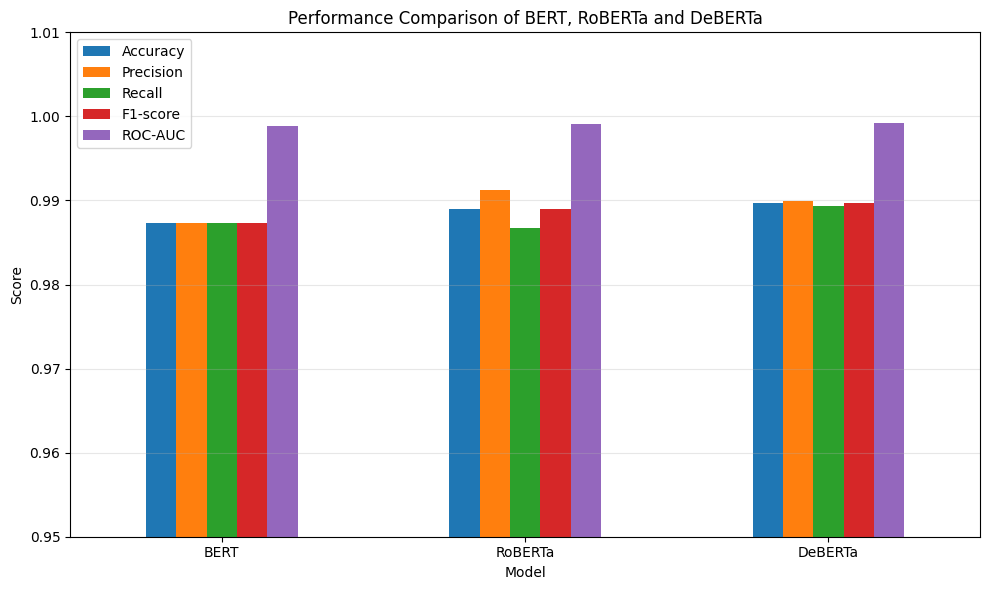

In [18]:
import matplotlib.pyplot as plt

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "ROC-AUC"
]

plot_df = comparison.set_index("Model")[metrics]

ax = plot_df.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Performance Comparison of BERT, RoBERTa and DeBERTa")
plt.ylabel("Score")
plt.ylim(0.95,1.01)
plt.xticks(rotation=0)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "performance_comparison.png",
    dpi=300
)

plt.show()

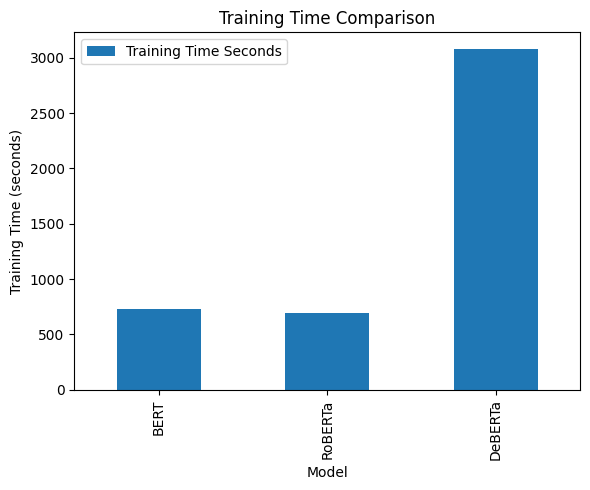

In [19]:
comparison.plot(
    x="Model",
    y="Training Time Seconds",
    kind="bar",
    figsize=(6,5)
)

plt.ylabel("Training Time (seconds)")
plt.title("Training Time Comparison")

plt.tight_layout()

plt.savefig(
    "training_time_comparison.png",
    dpi=300
)

plt.show()

In [20]:
comparison
bert
roberta
deberta

,text,label,source,email_type,urls,sample_id,predicted_label,predicted_class,legitimate_probability,phishing_probability,correct_prediction
0,"Gallup Powerline Agmt. Mr. McGee, Per Gerald's...",0,Enron,legitimate,0,EMAIL_019844,0,Legitimate,0.999986,0.000014,True
1,Â Â Â Â Â Covering All 50 States 3 Executive P...,1,Paper2,phishing,0,EMAIL_000034,1,Phishing,0.000151,0.999849,True
2,genie video update i have received many inquir...,0,Paper2,legitimate,0,EMAIL_018069,0,Legitimate,0.999898,0.000102,True
3,123 Theres something in store for you! Excell...,1,CEAS,phishing,1,EMAIL_011143,1,Phishing,0.000026,0.999974,True
4,best rx - - - - 10802244619786473915 hi varou ...,1,Paper2,phishing,0,EMAIL_005739,1,Phishing,0.000032,0.999968,True
...,...,...,...,...,...,...,...,...,...,...,...
2995,custom design work corporate image can say a l...,1,Paper2,phishing,0,EMAIL_004370,1,Phishing,0.000067,0.999933,True
2996,*SAVE! SAVE! SAVE!* GENERIC BRAND MEDICATIONS ...,1,CEAS,phishing,1,EMAIL_005978,1,Phishing,0.000035,0.999965,True
2997,CNN Alerts: My Custom Alert Alert Name: My Cus...,1,CEAS,phishing,0,EMAIL_009137,1,Phishing,0.000029,0.999971,True
2998,FERC order re: imbalances A helpful FERC order...,0,Enron,legitimate,0,EMAIL_006605,0,Legitimate,0.999974,0.000026,True


In [21]:
import os
import shutil
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_FOLDER = "Final_Results"

os.makedirs(
    RESULTS_FOLDER,
    exist_ok=True
)

print("Results folder created.")

Results folder created.


In [22]:
comparison.to_csv(
    f"{RESULTS_FOLDER}/final_model_comparison.csv",
    index=False
)

comparison

,Model,Checkpoint,Accuracy,Precision,Recall,F1-score,ROC-AUC,Training Time Seconds,Best Checkpoint,Maximum Sequence Length,Epochs,Learning Rate,Precision Mode
0,BERT,bert-base-uncased,0.987333,0.987333,0.987333,0.987333,0.998907,732.144890,./final_models/bert/checkpoint-2625,NaN,NaN,NaN,NaN
1,RoBERTa,roberta-base,0.989000,0.991293,0.986667,0.988974,0.999080,695.516380,./final_models/roberta/checkpoint-1750,NaN,NaN,NaN,NaN
2,DeBERTa,microsoft/deberta-v3-base,0.989667,0.989993,0.989333,0.989663,0.999216,3077.268993,NaN,256.0,3.0,0.00001,FP32


In [23]:
comparison_rounded = comparison.copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "ROC-AUC"
]

for column in metric_columns:
    if column in comparison_rounded.columns:
        comparison_rounded[column] = (
            comparison_rounded[column]
            .astype(float)
            .round(4)
        )

if "Training Time Seconds" in comparison_rounded.columns:
    comparison_rounded[
        "Training Time Seconds"
    ] = (
        comparison_rounded[
            "Training Time Seconds"
        ]
        .astype(float)
        .round(2)
    )

comparison_rounded.to_csv(
    f"{RESULTS_FOLDER}/final_model_comparison_rounded.csv",
    index=False
)

comparison_rounded

,Model,Checkpoint,Accuracy,Precision,Recall,F1-score,ROC-AUC,Training Time Seconds,Best Checkpoint,Maximum Sequence Length,Epochs,Learning Rate,Precision Mode
0,BERT,bert-base-uncased,0.9873,0.9873,0.9873,0.9873,0.9989,732.14,./final_models/bert/checkpoint-2625,NaN,NaN,NaN,NaN
1,RoBERTa,roberta-base,0.9890,0.9913,0.9867,0.9890,0.9991,695.52,./final_models/roberta/checkpoint-1750,NaN,NaN,NaN,NaN
2,DeBERTa,microsoft/deberta-v3-base,0.9897,0.9900,0.9893,0.9897,0.9992,3077.27,NaN,256.0,3.0,0.00001,FP32


In [24]:
comparison_rounded = comparison.copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "ROC-AUC"
]

for column in metric_columns:
    if column in comparison_rounded.columns:
        comparison_rounded[column] = (
            comparison_rounded[column]
            .astype(float)
            .round(4)
        )

if "Training Time Seconds" in comparison_rounded.columns:
    comparison_rounded[
        "Training Time Seconds"
    ] = (
        comparison_rounded[
            "Training Time Seconds"
        ]
        .astype(float)
        .round(2)
    )

comparison_rounded.to_csv(
    f"{RESULTS_FOLDER}/final_model_comparison_rounded.csv",
    index=False
)

comparison_rounded

,Model,Checkpoint,Accuracy,Precision,Recall,F1-score,ROC-AUC,Training Time Seconds,Best Checkpoint,Maximum Sequence Length,Epochs,Learning Rate,Precision Mode
0,BERT,bert-base-uncased,0.9873,0.9873,0.9873,0.9873,0.9989,732.14,./final_models/bert/checkpoint-2625,NaN,NaN,NaN,NaN
1,RoBERTa,roberta-base,0.9890,0.9913,0.9867,0.9890,0.9991,695.52,./final_models/roberta/checkpoint-1750,NaN,NaN,NaN,NaN
2,DeBERTa,microsoft/deberta-v3-base,0.9897,0.9900,0.9893,0.9897,0.9992,3077.27,NaN,256.0,3.0,0.00001,FP32


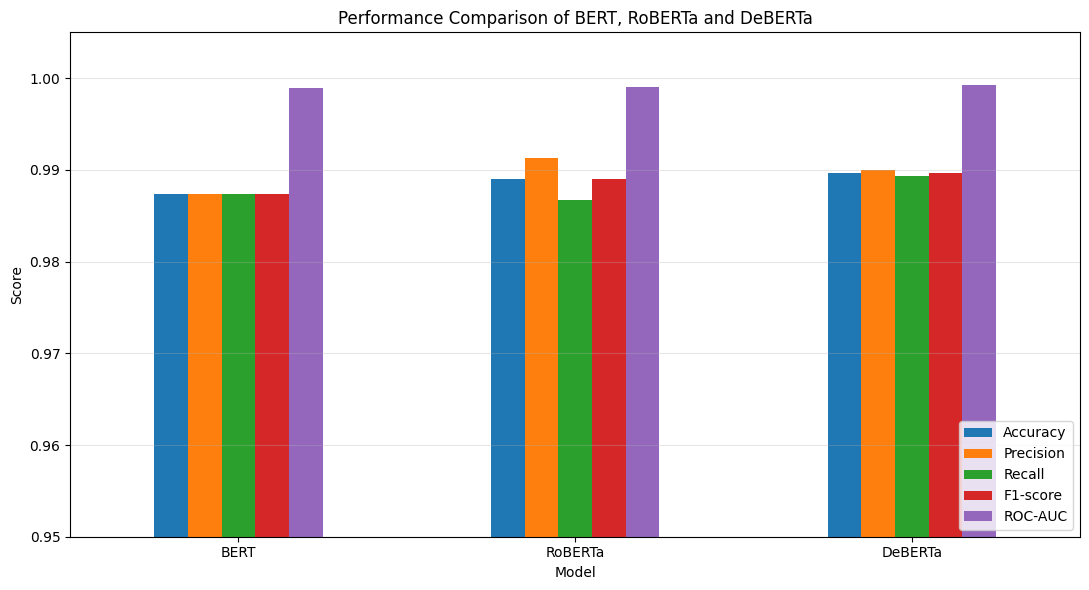

In [25]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "ROC-AUC"
]

plot_df = comparison.set_index(
    "Model"
)[metrics]

plot_df.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0.95, 1.005)
plt.title(
    "Performance Comparison of BERT, RoBERTa and DeBERTa"
)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()

plt.savefig(
    f"{RESULTS_FOLDER}/performance_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

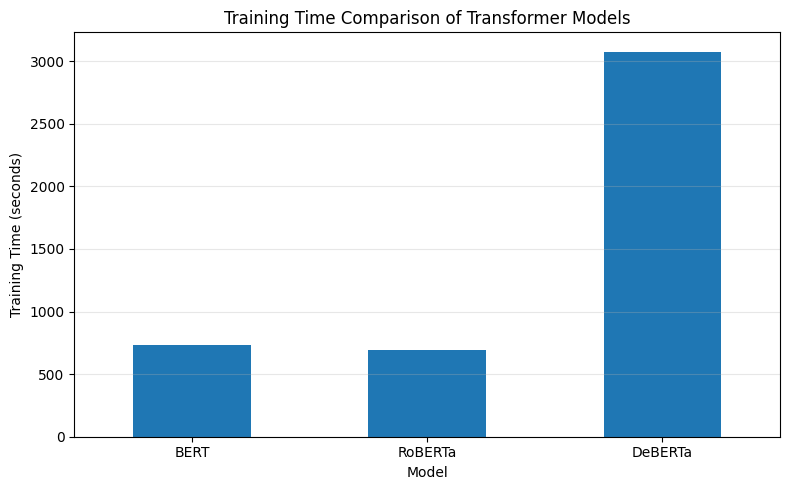

In [26]:
if "Training Time Seconds" in comparison.columns:
    comparison.plot(
        x="Model",
        y="Training Time Seconds",
        kind="bar",
        figsize=(8, 5),
        legend=False
    )

    plt.ylabel("Training Time (seconds)")
    plt.xlabel("Model")
    plt.title(
        "Training Time Comparison of Transformer Models"
    )
    plt.xticks(rotation=0)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()

    plt.savefig(
        f"{RESULTS_FOLDER}/training_time_comparison.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()
else:
    print(
        "Training Time Seconds column was not found."
    )

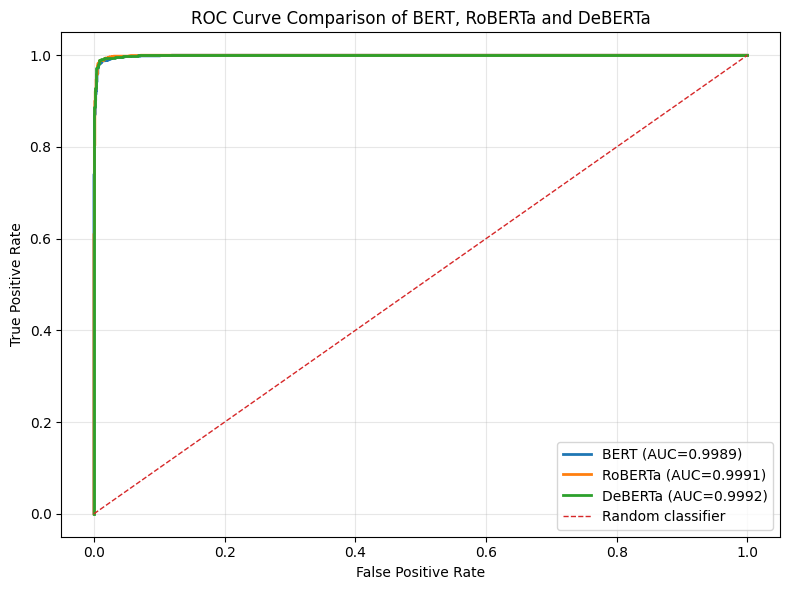

In [27]:
from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)

models = {
    "BERT": bert,
    "RoBERTa": roberta,
    "DeBERTa": deberta
}

plt.figure(figsize=(8, 6))

roc_summary = []

for model_name, frame in models.items():
    y_true = frame["label"]
    y_probability = frame[
        "phishing_probability"
    ]

    fpr, tpr, thresholds = roc_curve(
        y_true,
        y_probability
    )

    auc_value = roc_auc_score(
        y_true,
        y_probability
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{model_name} (AUC={auc_value:.4f})"
    )

    roc_summary.append({
        "Model": model_name,
        "ROC-AUC": auc_value
    })

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(
    "ROC Curve Comparison of BERT, RoBERTa and DeBERTa"
)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    f"{RESULTS_FOLDER}/combined_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [28]:
roc_summary_df = pd.DataFrame(
    roc_summary
)

roc_summary_df.to_csv(
    f"{RESULTS_FOLDER}/roc_auc_summary.csv",
    index=False
)

roc_summary_df

,Model,ROC-AUC
0,BERT,0.998907
1,RoBERTa,0.999080
2,DeBERTa,0.999216


In [29]:
bert.to_csv(
    f"{RESULTS_FOLDER}/bert_test_predictions.csv",
    index=False
)

roberta.to_csv(
    f"{RESULTS_FOLDER}/roberta_test_predictions.csv",
    index=False
)

deberta.to_csv(
    f"{RESULTS_FOLDER}/deberta_test_predictions.csv",
    index=False
)

In [30]:
from sklearn.metrics import confusion_matrix

error_rows = []

for model_name, frame in models.items():
    matrix = confusion_matrix(
        frame["label"],
        frame["predicted_label"]
    )

    tn, fp, fn, tp = matrix.ravel()

    error_rows.append({
        "Model": model_name,
        "True Negatives": tn,
        "False Positives": fp,
        "False Negatives": fn,
        "True Positives": tp,
        "Total Errors": fp + fn
    })

error_comparison = pd.DataFrame(
    error_rows
)

error_comparison.to_csv(
    f"{RESULTS_FOLDER}/confusion_matrix_summary.csv",
    index=False
)

error_comparison

,Model,True Negatives,False Positives,False Negatives,True Positives,Total Errors
0,BERT,1481,19,19,1481,38
1,RoBERTa,1487,13,20,1480,33
2,DeBERTa,1485,15,16,1484,31


In [31]:
figure_files = [
    "bert_confusion_matrix.png",
    "bert_roc_curve.png",
    "roberta_confusion_matrix.png",
    "roberta_roc_curve.png",
    "deberta_confusion_matrix.png",
    "deberta_roc_curve.png"
]

for filename in figure_files:
    if os.path.exists(filename):
        shutil.copy(
            filename,
            f"{RESULTS_FOLDER}/{filename}"
        )

        print("Copied:", filename)
    else:
        print("Not found:", filename)

Not found: bert_confusion_matrix.png
Not found: bert_roc_curve.png
Not found: roberta_confusion_matrix.png
Not found: roberta_roc_curve.png
Not found: deberta_confusion_matrix.png
Not found: deberta_roc_curve.png


In [32]:
result_files = [
    "bert_results.csv",
    "roberta_results.csv",
    "deberta_results.csv",

    "bert_classification_report.csv",
    "roberta_classification_report.csv",
    "deberta_classification_report.csv",

    "bert_training_log.csv",
    "roberta_training_log.csv",
    "deberta_training_log.csv",

    "deberta_experiment_information.csv"
]

for filename in result_files:
    if os.path.exists(filename):
        shutil.copy(
            filename,
            f"{RESULTS_FOLDER}/{filename}"
        )

        print("Copied:", filename)
    else:
        print("Not found:", filename)

Copied: bert_results.csv
Copied: roberta_results.csv
Copied: deberta_results.csv
Not found: bert_classification_report.csv
Not found: roberta_classification_report.csv
Not found: deberta_classification_report.csv
Not found: bert_training_log.csv
Not found: roberta_training_log.csv
Not found: deberta_training_log.csv
Not found: deberta_experiment_information.csv


In [33]:
best_accuracy = comparison.loc[
    comparison["Accuracy"].idxmax()
]

best_recall = comparison.loc[
    comparison["Recall"].idxmax()
]

best_f1 = comparison.loc[
    comparison["F1-score"].idxmax()
]

summary_text = f"""
FINAL MODEL COMPARISON SUMMARY

Best accuracy:
{best_accuracy['Model']} = {best_accuracy['Accuracy']:.4f}

Best phishing recall:
{best_recall['Model']} = {best_recall['Recall']:.4f}

Best F1-score:
{best_f1['Model']} = {best_f1['F1-score']:.4f}

Models evaluated:
BERT, RoBERTa and DeBERTa

Test-set size:
{len(bert)} emails

Evaluation metrics:
Accuracy, Precision, Recall, F1-score, ROC-AUC,
Confusion Matrix and Training Time.
"""

with open(
    f"{RESULTS_FOLDER}/final_results_summary.txt",
    "w",
    encoding="utf-8"
) as file:
    file.write(summary_text)

print(summary_text)


FINAL MODEL COMPARISON SUMMARY

Best accuracy:
DeBERTa = 0.9897

Best phishing recall:
DeBERTa = 0.9893

Best F1-score:
DeBERTa = 0.9897

Models evaluated:
BERT, RoBERTa and DeBERTa

Test-set size:
3000 emails

Evaluation metrics:
Accuracy, Precision, Recall, F1-score, ROC-AUC,
Confusion Matrix and Training Time.



In [34]:
for root, directories, filenames in os.walk(
    RESULTS_FOLDER
):
    level = root.replace(
        RESULTS_FOLDER,
        ""
    ).count(os.sep)

    indent = "    " * level

    print(
        f"{indent}{os.path.basename(root)}/"
    )

    for filename in sorted(filenames):
        print(
            f"{indent}    {filename}"
        )

Final_Results/
    bert_results.csv
    bert_test_predictions.csv
    combined_roc_curve.png
    confusion_matrix_summary.csv
    deberta_results.csv
    deberta_test_predictions.csv
    final_model_comparison.csv
    final_model_comparison_rounded.csv
    final_results_summary.txt
    performance_comparison.png
    roberta_results.csv
    roberta_test_predictions.csv
    roc_auc_summary.csv
    training_time_comparison.png


In [35]:
shutil.make_archive(
    "Final_Transformer_Results",
    "zip",
    RESULTS_FOLDER
)

print(
    "ZIP created:",
    os.path.exists(
        "Final_Transformer_Results.zip"
    )
)

print(
    "ZIP size:",
    round(
        os.path.getsize(
            "Final_Transformer_Results.zip"
        ) / 1024**2,
        2
    ),
    "MB"
)

ZIP created: True
ZIP size: 4.87 MB


In [36]:
from google.colab import files

files.download(
    "Final_Transformer_Results.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>